# ERCOT TX-123BT base-case anatomy (prompt 26 T4)

Runs against the newest committed extract: `extracts/base_2019` when the
base collector has landed, else `extracts/smoke_3d` with a **PRELIMINARY**
banner. To upgrade after the base lands: `git pull`, then re-run all cells
— nothing else changes.

Standing conventions (prompt 26):

- **HYDRO is excluded from every curtailment figure and ranking.** The 10
  hydro units carry a scalar `p_max` (no timeseries), so Prescient's
  `p_max − pg` counts each hour of routine backing-down as fake
  "renewables curtailment" (CONFIG_ERCOT.md, hydro row).
- Any absolute cost/starts figure carries the run's RUC gap summary
  (median/P95 final MIPGap, % truncated days).
- The cross-system panel shows **structural quantities only** — never cost
  levels across systems (TL=120 vs RTS full convergence = two optimality
  standards, i.e. comparing two solvers' patience, not two grids).
- DA ≡ RT here (all three profile pairs byte-identical): unserved energy
  reflects genuine scarcity only; the RTS conservative-DA mechanism cannot
  operate the same way.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"font.weight": "bold", "axes.labelweight": "bold",
                     "axes.titleweight": "bold",
                     # literal "$" in labels/captions, no mathtext
                     "text.parse_math": False})

NB_DIR = Path.cwd()
ERCOT = NB_DIR.parent                      # trial_0826/ercot
TRIAL = ERCOT.parent                       # trial_0826
REPO = TRIAL.parent                        # repo root

BASE_X = ERCOT / "extracts" / "base_2019"
SMOKE_X = ERCOT / "extracts" / "smoke_3d"
EXTRACT = BASE_X if (BASE_X / "hourly_summary.csv").exists() else SMOKE_X
PRELIMINARY = EXTRACT == SMOKE_X

hourly = pd.read_csv(EXTRACT / "hourly_summary.csv")
gens = pd.read_csv(EXTRACT / "gen_summary.csv")
ren = pd.read_csv(EXTRACT / "renewables.csv.gz")
lmps = pd.read_csv(EXTRACT / "bus_lmps.csv.gz")
ruc = pd.read_csv(EXTRACT / "ruc_quality.csv")
n_hours, n_days = len(hourly), len(hourly) // 24

if PRELIMINARY:
    print("=" * 72)
    print("PRELIMINARY — built against the 3-DAY SMOKE extract (smoke_3d,")
    print("RUC TimeLimit 600 s characterization config, Jan 1-3 2019).")
    print("The full-year base (TL=120) has not landed yet; every run-derived")
    print("figure below is a 3-day preview. Re-run all cells after the base")
    print("collector pushes extracts/base_2019.")
    print("=" * 72)
else:
    print(f"Extract: {EXTRACT.name} ({n_days} days, {n_hours} h)")

PRELIMINARY — built against the 3-DAY SMOKE extract (smoke_3d,
RUC TimeLimit 600 s characterization config, Jan 1-3 2019).
The full-year base (TL=120) has not landed yet; every run-derived
figure below is a 3-day preview. Re-run all cells after the base
collector pushes extracts/base_2019.


## RUC solution quality (rider (i) of the TL=120 decision)

Per-day final MIPGap / termination status / SolCount, parsed by the
collector from the Gurobi logs (`output_solver_logs=True` on all runs).
**SolCount = 0 on any day is run-invalidating — reported, never averaged
over.** This summary is stamped onto every absolute cost/starts figure.

In [2]:
gap_med = ruc["final_gap_pct"].median()
gap_p95 = ruc["final_gap_pct"].quantile(0.95)
gap_max = ruc["final_gap_pct"].max()
truncated = ~ruc["status"].astype(str).str.upper().str.startswith("OPTIMAL")
pct_trunc = 100.0 * truncated.mean()
solzero = ruc[ruc["sol_count"] == 0]

GAP_NOTE = (f"RUC quality: median gap {gap_med:.2f}%, P95 {gap_p95:.2f}%, "
            f"max {gap_max:.2f}%; {pct_trunc:.0f}% of days truncated "
            f"({int(truncated.sum())}/{len(ruc)})")
if PRELIMINARY:
    FOOTER = ("ERCOT: DA≡RT (no forecast error); PRELIMINARY 3-day smoke at "
              "RUC TimeLimit 600 s (base config: TimeLimit 120 s)")
else:
    FOOTER = ("ERCOT: DA≡RT (no forecast error); RUC TimeLimit 120 s "
              f"({pct_trunc:.0f}% days truncated)")

print(GAP_NOTE)
if len(solzero):
    print(f"*** RUN-INVALIDATING: {len(solzero)} day(s) with SolCount=0 "
          f"(no incumbent at the time limit): {solzero['ruc_date'].tolist()} ***")
else:
    print("SolCount=0 days: none")
ruc.describe(include="all").T

RUC quality: median gap 1.00%, P95 1.00%, max 1.00%; 0% of days truncated (0/3)
SolCount=0 days: none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ruc_date,3,3,start_date,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final_gap_pct,3.0,NaN,NaN,NaN,0.990633,0.009521,0.9797,0.9874,0.9951,0.9961,0.9971
sol_count,3.0,NaN,NaN,NaN,10.0,0.0,10.0,10.0,10.0,10.0,10.0
status,3,1,OPTIMAL,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
solve_time_s,3.0,NaN,NaN,NaN,347.412836,145.925478,227.602171,266.156421,304.71067,407.318168,509.925665
ruc_cost,3.0,NaN,NaN,NaN,23755220.926667,7722081.885955,15097769.21,20666608.845,26235448.48,28083946.785,29932445.09


## 1. Curtailment: duration curve + site concentration

Wind + solar only (**hydro excluded**, see conventions above). The site
ranking here is what block #4 confirms the screening slate against.

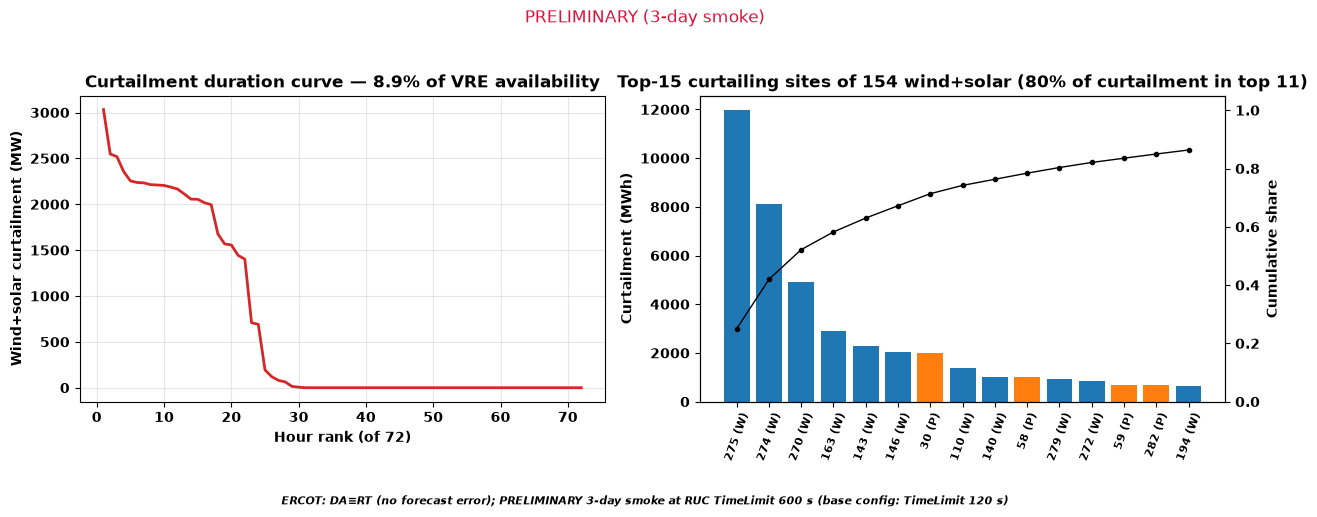

,Generator,unit_type,curtailment_mwh,output_mwh,pmax_mw
0,275,WIND,11966.584828,12887.465172,1038.999988
1,274,WIND,8128.431152,9682.118848,746.399988
2,270,WIND,4895.951315,8896.838685,578.999988
3,163,WIND,2910.584023,1491.425977,185.399988
4,143,WIND,2287.870000,3785.510000,238.499988
5,146,WIND,2021.600000,3684.370000,267.999999
6,30,PV,1980.630000,9817.770000,926.666667
7,110,WIND,1363.790000,4886.180000,338.599999
8,140,WIND,1009.360000,3616.280000,250.599999
9,58,PV,1004.970000,5361.070000,500.000000


In [3]:
vre = ren[ren["unit_type"].isin(["WIND", "PV"])].copy()
cur_h = vre.groupby(["Date", "Hour"])["Curtailment"].sum().sort_values(ascending=False)
vre["avail"] = vre["Output"] + vre["Curtailment"]
tot_avail = vre["avail"].sum()
cur_share = 100.0 * vre["Curtailment"].sum() / tot_avail

site = gens[gens["unit_type"].isin(["WIND", "PV"])].copy()
site = site.sort_values("curtailment_mwh", ascending=False).reset_index(drop=True)
top = site.head(15)
cum = site["curtailment_mwh"].cumsum() / max(site["curtailment_mwh"].sum(), 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(np.arange(1, len(cur_h) + 1), cur_h.values, lw=2, color="tab:red")
ax.set_xlabel(f"Hour rank (of {len(cur_h)})")
ax.set_ylabel("Wind+solar curtailment (MW)")
ax.set_title(f"Curtailment duration curve — {cur_share:.1f}% of VRE availability")
ax.grid(alpha=0.3)

ax = axes[1]
colors = ["tab:blue" if t == "WIND" else "tab:orange" for t in top["unit_type"]]
labels = [f"{g} ({t[0]})" for g, t in zip(top["Generator"].astype(str), top["unit_type"])]
ax.bar(range(len(top)), top["curtailment_mwh"], color=colors)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(labels, rotation=70, fontsize=8)
ax.set_ylabel("Curtailment (MWh)")
n80 = int((cum < 0.8).sum()) + 1
ax.set_title(f"Top-15 curtailing sites of {len(site)} wind+solar "
             f"(80% of curtailment in top {n80})")
ax2 = ax.twinx()
ax2.plot(range(len(top)), cum.head(15), "k.-", lw=1)
ax2.set_ylabel("Cumulative share")
ax2.set_ylim(0, 1.05)

fig.suptitle("PRELIMINARY (3-day smoke)" if PRELIMINARY else "Full-year base",
             y=1.04, color="crimson" if PRELIMINARY else "black")
fig.text(0.5, -0.06, FOOTER, ha="center", fontsize=8, style="italic")
plt.tight_layout()
plt.show()
top[["Generator", "unit_type", "curtailment_mwh", "output_mwh", "pmax_mw"]]

## 2. LMP distribution

**Pricing-config context (mandated caption):** this run uses
`day_ahead_pricing = aCHP` (the Prescient 2.2.x default) with
`price_threshold = 500`. The source paper's $17.98 mean was generated
under **LMP pricing + threshold 5000** — a different mechanism, so means
legitimately differ; $17.98 is context, **never a validation target**.
Price history (Kay, 09-20): his own prior 123-bus runs under LMP pricing
gave means ≈ $10 on *both* fleets (2019 and GTEP-2035), persistently below
the paper; the 09-20 smoke under aCHP gave $14.79 (3 January days). So the
pricing mechanism, not the fleet, is the dominant price-level driver —
aCHP amortizes commitment costs into prices and lifts the near-zero-LMP
hours. **Source-paper price-level difference: mechanism explanation
pending (Kay).**

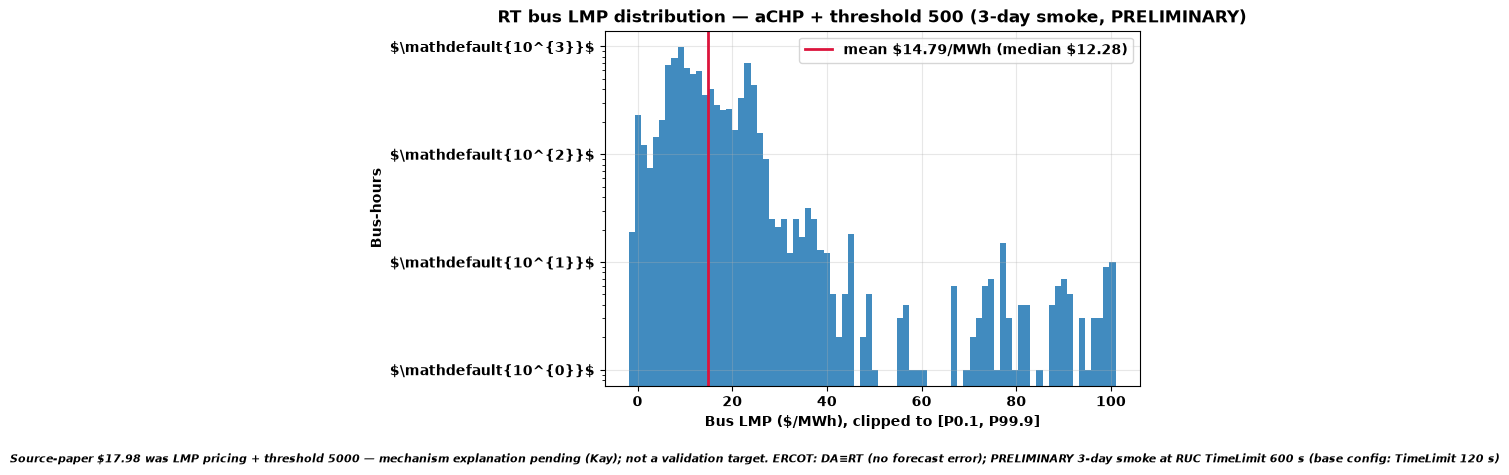

mean $14.79, median $12.28 per MWh over 8,856 bus-hours
-$1000-floor artifacts (LMP <= -900): 0
scarcity-side hours near the 500 threshold (LMP >= 450): 0


In [4]:
mean_lmp = lmps["LMP"].mean()
med_lmp = lmps["LMP"].median()
floor_hits = int((lmps["LMP"] <= -900).sum())
hi_hits = int((lmps["LMP"] >= 450).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))
lo, hi = np.percentile(lmps["LMP"], [0.1, 99.9])
ax.hist(lmps["LMP"].clip(lo, hi), bins=80, color="tab:blue", alpha=0.85)
ax.axvline(mean_lmp, color="crimson", lw=2,
           label=f"mean ${mean_lmp:.2f}/MWh (median ${med_lmp:.2f})")
ax.set_xlabel("Bus LMP ($/MWh), clipped to [P0.1, P99.9]")
ax.set_ylabel("Bus-hours")
ax.set_yscale("log")
ax.set_title(f"RT bus LMP distribution — aCHP + threshold 500 "
             f"({'3-day smoke, PRELIMINARY' if PRELIMINARY else f'{n_days}-day base'})")
ax.legend()
ax.grid(alpha=0.3)
fig.text(0.5, -0.04,
         "Source-paper $17.98 was LMP pricing + threshold 5000 — mechanism "
         "explanation pending (Kay); not a validation target. " + FOOTER,
         ha="center", fontsize=8, style="italic")
plt.tight_layout()
plt.show()

print(f"mean ${mean_lmp:.2f}, median ${med_lmp:.2f} per MWh over {len(lmps):,} bus-hours")
print(f"-$1000-floor artifacts (LMP <= -900): {floor_hits}")
print(f"scarcity-side hours near the 500 threshold (LMP >= 450): {hi_hits}")

## 3. Load / net-load anatomy (run window)

Net load = demand − wind/solar availability (output + curtailment; hydro
excluded — its scalar-p_max output is dispatch, not availability). DA ≡ RT,
so the RT series shown *is* the DA series.

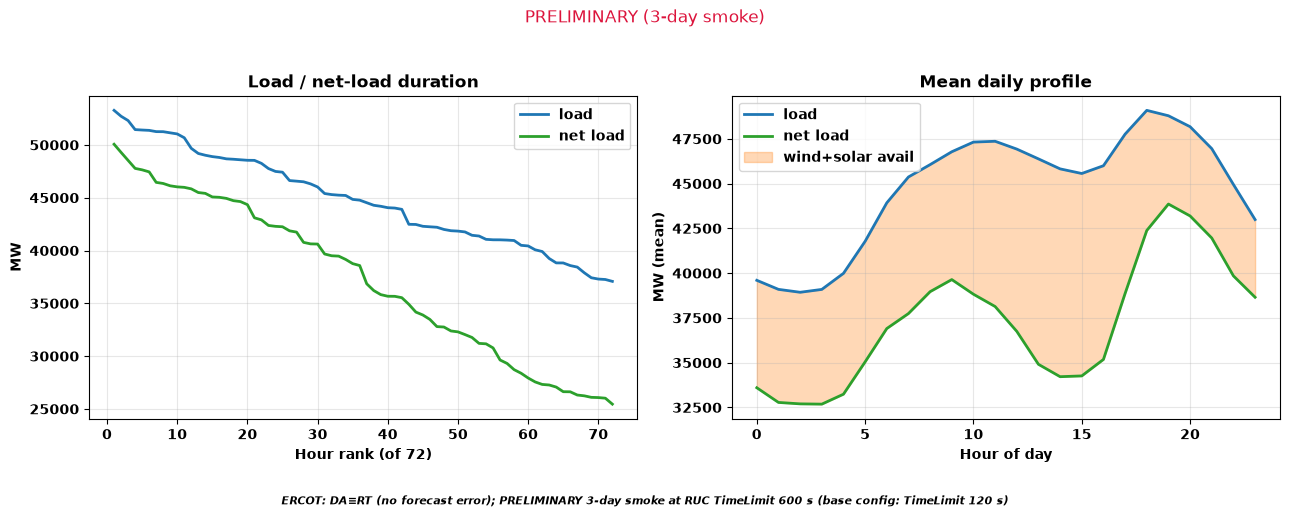

peak load (window): 53,277 MW; min net load: 25,454 MW; shed total: 0.0 MWh; reserve shortfall total: 0.0 MWh


In [5]:
dem = hourly[["Date", "Hour", "Demand"]].copy()
avail_h = (vre.groupby(["Date", "Hour"])["avail"].sum()
           .rename("vre_avail").reset_index())
nl = dem.merge(avail_h, on=["Date", "Hour"], how="left").fillna({"vre_avail": 0.0})
nl["net_load"] = nl["Demand"] - nl["vre_avail"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for col, c in [("Demand", "tab:blue"), ("net_load", "tab:green")]:
    ax.plot(np.arange(1, len(nl) + 1), np.sort(nl[col])[::-1], lw=2, color=c,
            label={"Demand": "load", "net_load": "net load"}[col])
ax.set_xlabel(f"Hour rank (of {len(nl)})")
ax.set_ylabel("MW")
ax.set_title("Load / net-load duration")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
prof = nl.groupby("Hour")[["Demand", "net_load", "vre_avail"]].mean()
ax.plot(prof.index, prof["Demand"], lw=2, color="tab:blue", label="load")
ax.plot(prof.index, prof["net_load"], lw=2, color="tab:green", label="net load")
ax.fill_between(prof.index, prof["net_load"], prof["Demand"],
                color="tab:orange", alpha=0.3, label="wind+solar avail")
ax.set_xlabel("Hour of day"); ax.set_ylabel("MW (mean)")
ax.set_title("Mean daily profile")
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle("PRELIMINARY (3-day smoke)" if PRELIMINARY else "Full-year base",
             y=1.04, color="crimson" if PRELIMINARY else "black")
fig.text(0.5, -0.06, FOOTER, ha="center", fontsize=8, style="italic")
plt.tight_layout(); plt.show()

print(f"peak load (window): {nl['Demand'].max():,.0f} MW; "
      f"min net load: {nl['net_load'].min():,.0f} MW; "
      f"shed total: {hourly['LoadShedding'].sum():,.1f} MWh; "
      f"reserve shortfall total: {hourly['ReserveShortfall'].sum():,.1f} MWh")

## 4. RTS vs ERCOT scaling panel (STRUCTURAL quantities only)

Fleet/capacity and load/net-load *shape* — **never cost levels across
systems** (TL=120 vs full convergence = different optimality standards).
The full-year ERCOT load/VRE shapes come from the vendored source profiles
(structural, run-independent), so this panel is full-year even while the
base is queued; RTS shapes come from the tracked RTS base case
(`trial_0826/base_case_pcm_test`). Curtailment *share* is run-derived and
carries the gap annotation.

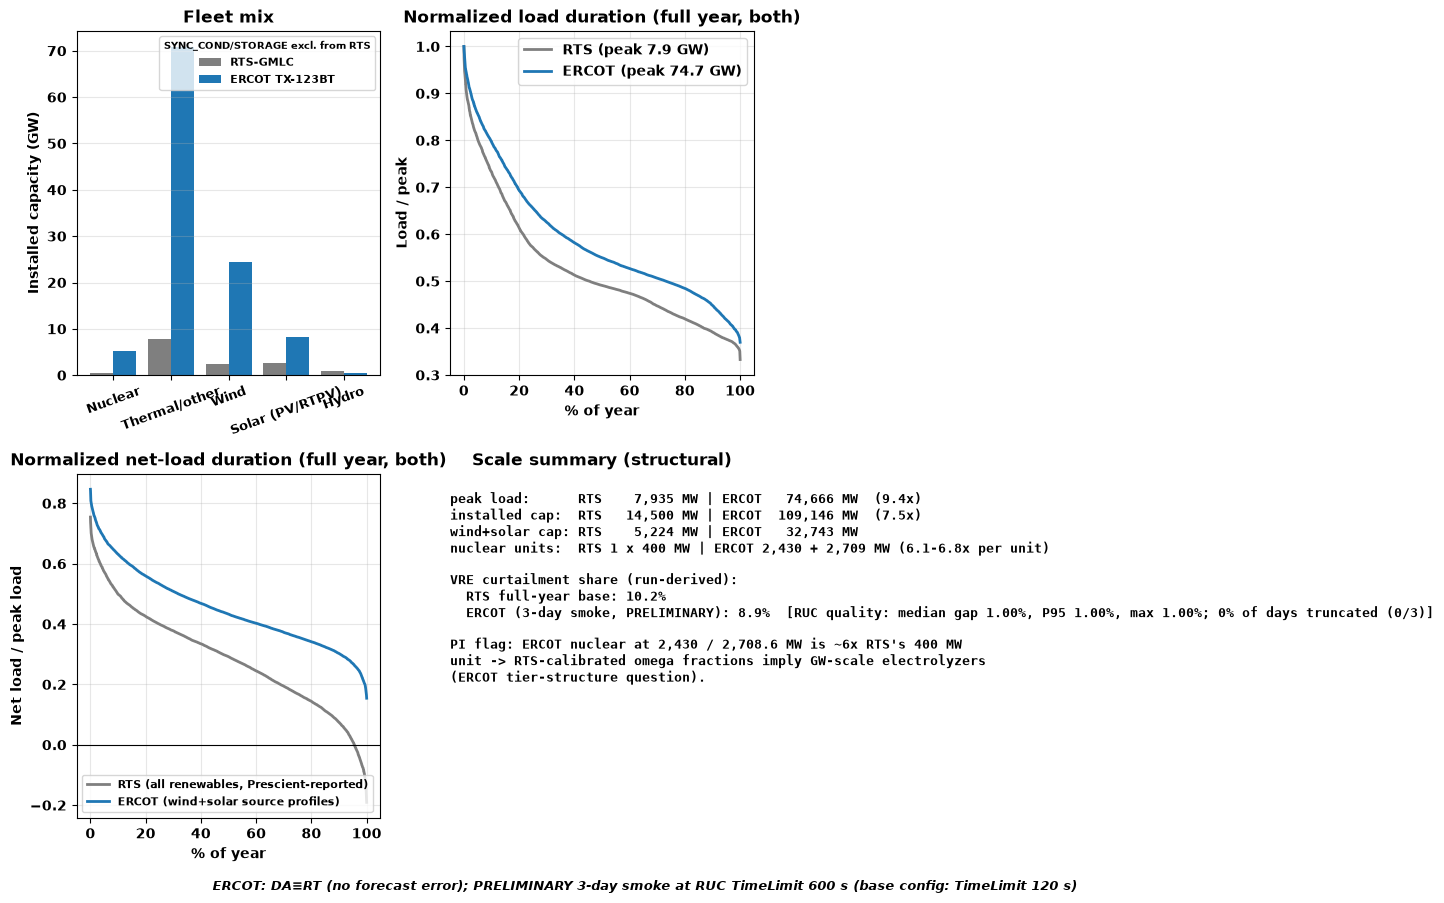

In [6]:
def cap_by_class(df):
    ut = df["Unit Type"].astype(str).str.upper()
    cls = np.select(
        [ut.str.startswith("NUC"), ut == "WIND",
         ut.str.contains("PV"), ut.str.startswith("HYD") | (ut == "ROR")],
        ["Nuclear", "Wind", "Solar (PV/RTPV)", "Hydro"], default="Thermal/other")
    out = df.assign(cls=cls).groupby("cls")["PMax MW"].sum()
    order = ["Nuclear", "Thermal/other", "Wind", "Solar (PV/RTPV)", "Hydro"]
    return out.reindex(order).fillna(0.0)

egen = pd.read_csv(ERCOT / "data" / "ercot123_2019" / "gen.csv")
rgen = pd.read_csv(REPO / "RTS_Data" / "SourceData" / "gen.csv")
rgen = rgen[~rgen["Unit Type"].isin(["SYNC_COND", "STORAGE"])]
ecap, rcap = cap_by_class(egen), cap_by_class(rgen)

# full-year structural profiles (first 8760 rows; rows 8761+ are the
# mandated 1/1/2020 lookahead padding)
def yearly(fname, n=8760):
    df = pd.read_csv(ERCOT / "data" / "ercot123_2019" / fname).iloc[:n]
    return df.drop(columns=["Year", "Month", "Day", "Period"]).sum(axis=1)

eload = yearly("DAY_AHEAD_load.csv")
evre = yearly("DAY_AHEAD_wind.csv") + yearly("DAY_AHEAD_solar.csv")
enet = eload - evre

rts = pd.read_csv(TRIAL / "base_case_pcm_test" / "hourly_summary.csv")
rload = rts["Demand"]
rnet = rts["Demand"] - (rts["RenewablesUsed"] + rts["RenewablesCurtailment"])
rts_cur_share = 100.0 * rts["RenewablesCurtailment"].sum() / max(
    (rts["RenewablesUsed"] + rts["RenewablesCurtailment"]).sum(), 1e-9)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax = axes[0, 0]
x = np.arange(len(ecap))
ax.bar(x - 0.2, rcap.values / 1e3, width=0.4, label="RTS-GMLC", color="tab:gray")
ax.bar(x + 0.2, ecap.values / 1e3, width=0.4, label="ERCOT TX-123BT", color="tab:blue")
ax.set_xticks(x); ax.set_xticklabels(ecap.index, rotation=20, fontsize=9)
ax.set_ylabel("Installed capacity (GW)")
ax.set_title("Fleet mix")
ax.legend(title="SYNC_COND/STORAGE excl. from RTS", fontsize=8, title_fontsize=7)
ax.grid(alpha=0.3, axis="y")

ax = axes[0, 1]
ax.plot(np.linspace(0, 100, len(rload)), np.sort(rload)[::-1] / rload.max(),
        lw=2, color="tab:gray", label=f"RTS (peak {rload.max()/1e3:.1f} GW)")
ax.plot(np.linspace(0, 100, len(eload)), np.sort(eload)[::-1] / eload.max(),
        lw=2, color="tab:blue", label=f"ERCOT (peak {eload.max()/1e3:.1f} GW)")
ax.set_xlabel("% of year"); ax.set_ylabel("Load / peak")
ax.set_title("Normalized load duration (full year, both)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(np.linspace(0, 100, len(rnet)), np.sort(rnet)[::-1] / rload.max(),
        lw=2, color="tab:gray", label="RTS (all renewables, Prescient-reported)")
ax.plot(np.linspace(0, 100, len(enet)), np.sort(enet)[::-1] / eload.max(),
        lw=2, color="tab:blue", label="ERCOT (wind+solar source profiles)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("% of year"); ax.set_ylabel("Net load / peak load")
ax.set_title("Normalized net-load duration (full year, both)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.axis("off")
enuc = egen.loc[egen["Unit Type"] == "NUC", "PMax MW"].sort_values().tolist()
rnuc = float(rgen.loc[rgen["Unit Type"] == "NUCLEAR", "PMax MW"].sum())
lines = [
    f"peak load:      RTS {rload.max():>8,.0f} MW | ERCOT {eload.max():>8,.0f} MW"
    f"  ({eload.max()/rload.max():.1f}x)",
    f"installed cap:  RTS {rcap.sum():>8,.0f} MW | ERCOT {ecap.sum():>8,.0f} MW"
    f"  ({ecap.sum()/rcap.sum():.1f}x)",
    f"wind+solar cap: RTS {rcap['Wind']+rcap['Solar (PV/RTPV)']:>8,.0f} MW | "
    f"ERCOT {ecap['Wind']+ecap['Solar (PV/RTPV)']:>8,.0f} MW",
    f"nuclear units:  RTS 1 x {rnuc:,.0f} MW | ERCOT "
    + " + ".join(f"{u:,.0f}" for u in enuc)
    + f" MW ({min(enuc)/rnuc:.1f}-{max(enuc)/rnuc:.1f}x per unit)",
    "",
    f"VRE curtailment share (run-derived):",
    f"  RTS full-year base: {rts_cur_share:.1f}%",
    f"  ERCOT ({'3-day smoke, PRELIMINARY' if PRELIMINARY else f'{n_days}-day base'}):"
    f" {cur_share:.1f}%  [{GAP_NOTE}]",
    "",
    "PI flag: ERCOT nuclear at 2,430 / 2,708.6 MW is ~6x RTS's 400 MW",
    "unit -> RTS-calibrated omega fractions imply GW-scale electrolyzers",
    "(ERCOT tier-structure question).",
]
ax.text(0.0, 0.95, "\n".join(lines), family="monospace", fontsize=9,
        va="top", transform=ax.transAxes)
ax.set_title("Scale summary (structural)")

fig.text(0.5, 0.005, FOOTER, ha="center", fontsize=9, style="italic")
plt.tight_layout(rect=(0, 0.02, 1, 1)); plt.show()

## Open flags carried out of this notebook

1. **ERCOT tier structure (PI question):** nuclear at 2,430 / 2,708.6 MW —
   ~6× RTS's single 400 MW unit — so RTS-calibrated ω fractions imply
   GW-scale electrolyzers. Needs a PI decision before the ERCOT campaign
   tiers are drawn.
2. **Hydro treatment (PI question):** kept in the fleet with constant
   PMax (matches vendored gen.csv; GTEP dropped hydro entirely), excluded
   from all curtailment accounting here. Confirm or switch to drop.
3. **Degenerate-g4 verdict** (reserve shortfall ≡ 0): re-verified only on
   the actual TL=120 base — check the reserves extract when it lands
   before "degenerate" enters any figure caption.
4. Screening deltas are gated by the **replicate-spread noise ruler**
   (2 replicate rows in the screening wave): |Δ| ≫ spread or the delta is
   labeled "within solver noise".